In [1]:
import cv2
import sys
import numpy as np
import os

import matplotlib.pyplot as plt
from IPython.display import YouTubeVideo, display, HTML, Image, Video

opencv_path = "opencv/samples/data/"
opencvxtra_path = "opencv_extra/testdata/dnn/"

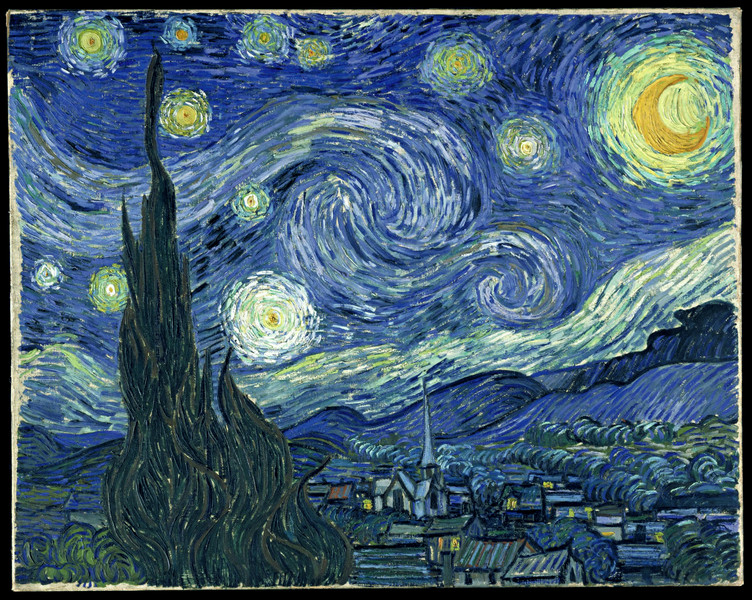

In [2]:
#| fig-align: center
Image("data/starry_night.jpg", width=240)

# from matplotlib import colormaps
#list(colormaps)

In [5]:
cv2.imshow('Starry night', starry_night)
cv2.waitKey(5000)
cv2.destroyWindow('Starry night')

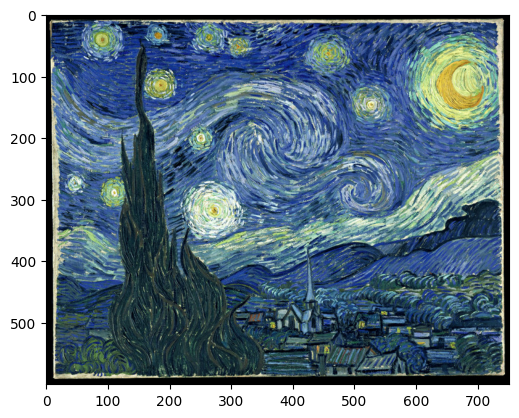

In [3]:
#| fig-align: center
starry_night = cv2.imread('data/starry_night.jpg')
img2 = cv2.cvtColor(starry_night, cv2.COLOR_BGR2RGB)

# Reversed (not correct)
plt.imshow(img2);
#plt.imshow(starry_night[:, :, 0], cmap='Blues');

#### Convert to grayscale

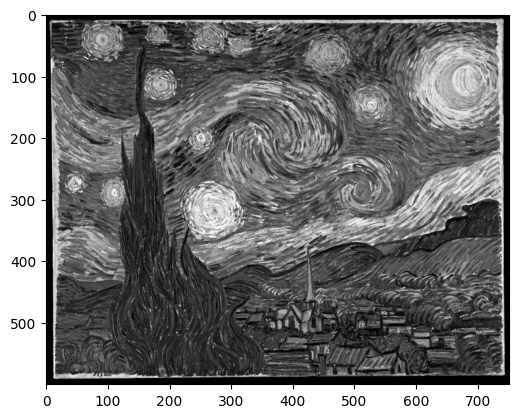

In [5]:
sn_grayscale = cv2.cvtColor(starry_night, cv2.COLOR_BGR2GRAY)
plt.imshow(sn_grayscale, cmap='gray');

#### Translate

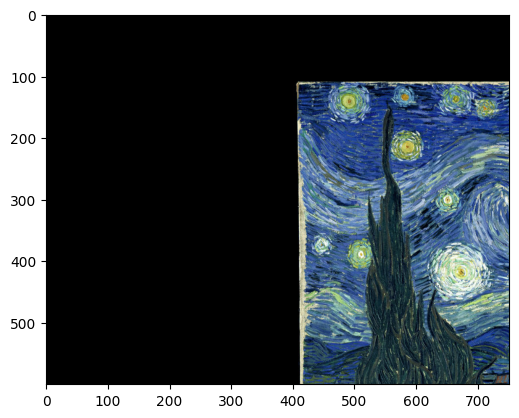

In [9]:
rows,cols = starry_night.shape[:2]
M = np.float32([[1,0,400],[0,1,100]])

sn_translate = cv2.warpAffine(starry_night, M, (cols, rows))
sn_translate_rgb = cv2.cvtColor(sn_translate, cv2.COLOR_BGR2RGB)
plt.imshow(sn_translate_rgb);

#### Rotate

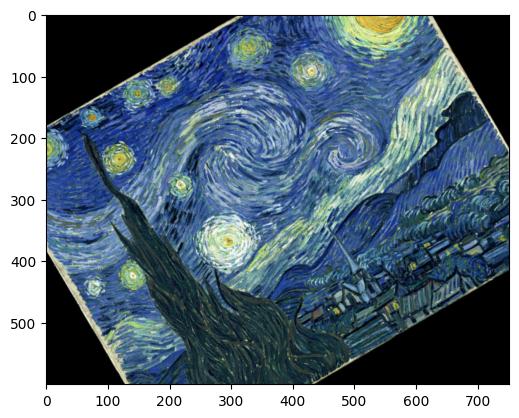

In [16]:
rotation_matrix = cv2.getRotationMatrix2D((0.5*cols, 0.5*rows), 30, 1)

sn_rotated = cv2.warpAffine(starry_night, rotation_matrix, (cols, rows))

sn_rotated_rgb = cv2.cvtColor(sn_rotated, cv2.COLOR_BGR2RGB)
plt.imshow(sn_rotated_rgb);

#### Resize

True

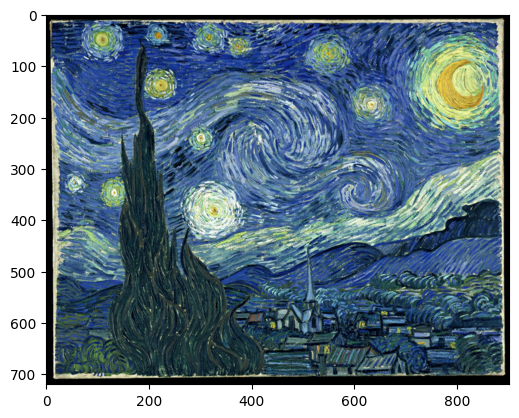

In [23]:
sn_resized = cv2.resize(starry_night, None,fx=1.2, fy=1.2, interpolation = cv2.INTER_CUBIC)

sn_resized_rgb = cv2.cvtColor(sn_resized, cv2.COLOR_BGR2RGB)
plt.imshow(sn_resized_rgb);
cv2.imwrite('data/test_sn.jpg', sn_resized)

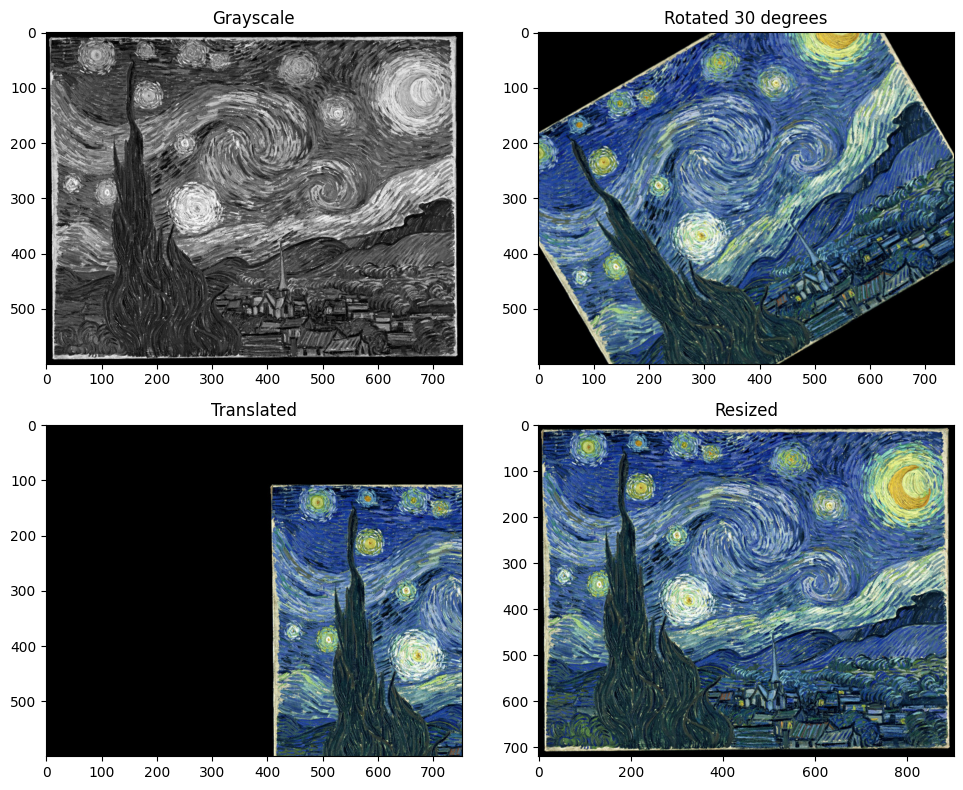

In [27]:
images = [sn_grayscale, sn_rotated_rgb, sn_translate_rgb, sn_resized_rgb]
titles = ['Grayscale', 'Rotated 30 degrees', 'Translated', 'Resized']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, img, title in zip(axes.flat, images, titles):
    if title == 'Grayscale':
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [6]:
cv2.imshow('Input image', starry_night)

cv2.waitKey()
cv2.destroyAllWindows()

## Canny Edge detection

In [14]:
img = cv2.imread('data/messi5.jpg')

cv2.imshow('Input image', img)

cv2.waitKey()
cv2.destroyAllWindows()

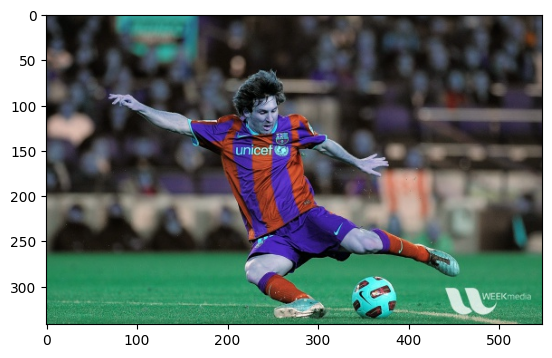

In [15]:
plt.imshow(img)

In [ ]:
edges = cv2.Canny(img, 100,200)

cv2.imshow('Input image', edges)

cv2.waitKey()
cv2.destroyAllWindows()

In [30]:
img = cv2.imread('data/messi5.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1,
                            minDist=50,
                            param1=50,
                            param2=22,      # low threshold to start, 18 works, 22 best
                            minRadius=18,
                            maxRadius=38)

print(circles)

[[[297.5 169.5  35.2]
  [231.5  96.5  20.5]
  [364.5 310.5  21. ]]]


In [12]:
img.shape

(342, 548, 3)

In [11]:
cv2.imshow('Input image', blurred)

cv2.waitKey()
cv2.destroyAllWindows()

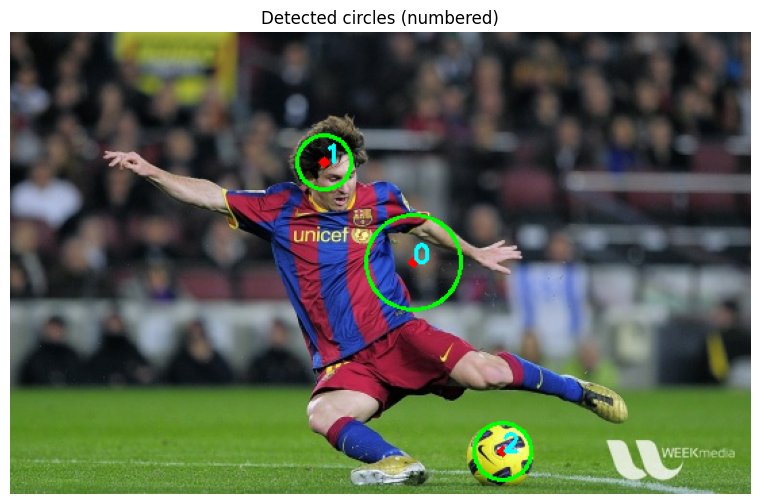

In [28]:
import numpy as np

img = cv2.imread('data/messi5.jpg')

if circles is not None:
    circles_rounded = np.uint16(np.around(circles))
    for i, c in enumerate(circles_rounded[0, :]):
        cv2.circle(img, (c[0], c[1]), c[2], (0, 255, 0), 2)   # circle
        cv2.circle(img, (c[0], c[1]), 2, (0, 0, 255), 3)       # centre dot
        cv2.putText(img, str(i), (c[0], c[1]),                  # label each one
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected circles (numbered)')
plt.axis('off')
plt.show()